# Materials Science Post-Processing Toolkit

A comprehensive Python toolkit for post-processing molecular dynamics and density functional theory calculations from LAMMPS and VASP.

## Features

- **LAMMPS Analysis**: Read trajectory files, calculate volumes, lattice parameters, and radial distribution functions (RDFs)
- **VASP Analysis**: Process OUTCAR and vasprun.xml files for energy convergence, stress analysis, and structural data
- **Advanced Plotting**: Professional visualization with customizable styles
- **RDF Calculations**: Partial RDF analysis using OVITO with time averaging
- **Cross-platform Comparison**: Compare VASP vs LAMMPS results side-by-side

## Requirements

The following Python packages are required. Install them using:

```bash
pip install ase matplotlib numpy scipy ovito pymatgen vasppy pickle
```

For conda users:
```bash
conda install ase matplotlib numpy scipy pymatgen
pip install ovito vasppy
```

## Quick Start

1. Update file paths in the example cells to match your data location
2. Run the import cell first
3. Choose the analysis type you need from the sections below
4. Modify parameters as needed for your specific system

---

In [1]:
# =============================================================================
# IMPORTS AND DEPENDENCIES
# =============================================================================
# Core scientific computing
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import pickle

# ASE (Atomic Simulation Environment) for structure manipulation
from ase.io.lammpsdata import read_lammps_data
from ase.io import read, iread
from ase.build import bulk
from ase.calculators.lj import LennardJones

# OVITO for advanced trajectory analysis and RDF calculations
from ovito.io import import_file
from ovito.modifiers import CoordinationAnalysisModifier, TimeAveragingModifier

# VASP analysis tools
from pymatgen.io.vasp import Xdatcar
from vasppy.rdf import RadialDistributionFunction

print("✓ All libraries imported successfully!")
print("Make sure you have the following packages installed:")
print("- ase, matplotlib, numpy, scipy, ovito, pymatgen, vasppy")

✓ All libraries imported successfully!
Make sure you have the following packages installed:
- ase, matplotlib, numpy, scipy, ovito, pymatgen, vasppy


---

# 1. LAMMPS Analysis

## 1.1 Basic LAMMPS File Reading and Properties

Read LAMMPS trajectory files and extract basic structural properties like volumes and lattice parameters.

**File formats supported:**
- `lammps-data` → LAMMPS data files (.lmp)
- `lammps-dump-binary` → LAMMPS binary dump files
- `lammps-dump-text` → LAMMPS text dump files (.lammpstrj)

**Index options for reading specific frames:**
- `index=0`: first configuration
- `index=-1`: last configuration (default)
- `index=':'`: all configurations
- `index='-3:'`: last three configurations
- `index='::2'`: every second frame

In [236]:
# =============================================================================
# LAMMPS BASIC ANALYSIS
# =============================================================================

# EXAMPLE: Read LAMMPS trajectory and get basic properties
# UPDATE THIS PATH to match your data location
data_file = '/Volumes/DATA/LAMMPS/interface@300K/NPT/50/dump.lammpstrj'

# Read specific frame (frame 5 in this example)
atoms = read(data_file, 5)
print(f"System information: {atoms}")
print(f"Number of atoms: {len(atoms)}")
print(f"Chemical formula: {atoms.get_chemical_formula()}")

# Get volume and lattice parameters
volume = atoms.get_volume()
print(f"Volume: {volume:.3f} Å³")

# Multiple volume measurements
volumes = [atoms.get_volume() for _ in range(5)]
print(f"Volumes (5 measurements): {volumes}")

# Lattice parameters
cell = atoms.get_cell()
lengths = cell.lengths()      # a, b, c
angles = cell.angles()        # alpha, beta, gamma

print(f"Lattice parameters (a, b, c): {lengths}")
print(f"Lattice angles (alpha, beta, gamma): {angles}")

System information: Atoms(symbols='H3840He1248', pbc=True, cell=[29.59298491172781, 31.22205663908552, 52.36753078965121])
Number of atoms: 5088
Chemical formula: H3840He1248
Volume: 48385.182 Å³
Volumes (5 measurements): [48385.18174221728, 48385.18174221728, 48385.18174221728, 48385.18174221728, 48385.18174221728]
Lattice parameters (a, b, c): [29.59298491 31.22205664 52.36753079]
Lattice angles (alpha, beta, gamma): [90. 90. 90.]


## 1.2 Equation of State Analysis

Generate equation of state curves by scaling the unit cell and calculating energies at different volumes.

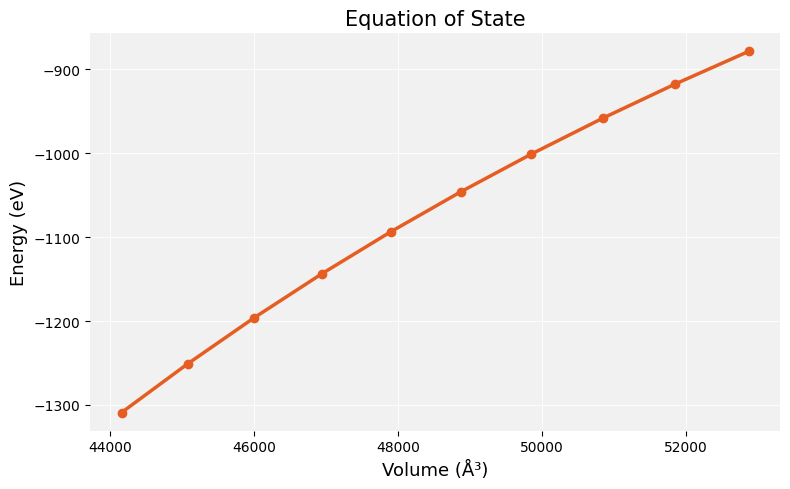

In [237]:
# =============================================================================
# EQUATION OF STATE CALCULATION
# =============================================================================

def calculate_equation_of_state(atoms, scale_range=(0.97, 1.03), num_points=10):
    """
    Calculate equation of state by scaling cell volume
    
    Parameters:
    atoms: ASE Atoms object
    scale_range: tuple of (min_scale, max_scale)
    num_points: number of volume points to calculate
    
    Returns:
    volumes, energies: lists of volumes and corresponding energies
    """
    energies = []
    scaled_volumes = []
    scalings = np.linspace(scale_range[0], scale_range[1], num_points)
    
    for scale in scalings:
        atoms_copy = atoms.copy()
        atoms_copy.set_cell(atoms.get_cell() * scale, scale_atoms=True)
        atoms_copy.calc = LennardJones()  # Using Lennard-Jones for example
        scaled_volumes.append(atoms_copy.get_volume())
        energies.append(atoms_copy.get_potential_energy())
    
    return scaled_volumes, energies

def plot_equation_of_state(volumes, energies, title="Equation of State"):
    """Plot equation of state with custom styling"""
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#f1f1f1")
    ax.grid(True, color='white', linestyle='-', alpha=0.8)
    ax.plot(volumes, energies, marker='o', color="#e65d22", lw=2.5)
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.xlabel('Volume (Å³)', fontsize=13)
    plt.ylabel('Energy (eV)', fontsize=13)
    plt.title(title, fontsize=15)
    plt.tight_layout()
    plt.show()

# EXAMPLE USAGE:
if 'atoms' in locals():
    volumes, energies = calculate_equation_of_state(atoms)
    plot_equation_of_state(volumes, energies)
else:
    print("Run the LAMMPS basic analysis cell first to load atoms")

## 1.3 Radial Distribution Function (RDF) Analysis

### Simple RDF from LAMMPS Output Files

Read and plot RDF data directly from LAMMPS rdf.dat output files.

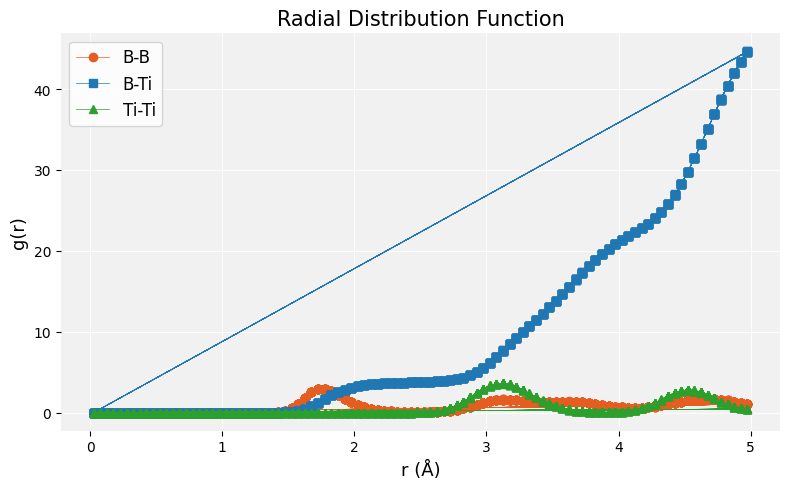

✓ Simple RDF plot generated successfully


In [246]:
# =============================================================================
# SIMPLE RDF PLOTTING FROM LAMMPS OUTPUT
# =============================================================================

def read_lammps_rdf(filename):
    """
    Read RDF data from LAMMPS rdf.dat file
    
    Parameters:
    filename: path to rdf.dat file
    
    Returns:
    r, rdf_data: distance array and RDF values for different pair types
    """
    data = []
    with open(filename, 'r') as f:
        for line in f:
            if line.startswith("#") or line.strip() == "":
                continue
            parts = line.split()
            if len(parts) < 8:
                continue
            data.append([float(x) for x in parts])
    
    data = np.array(data)
    r = data[:, 1]          # Distance
    rdf_12 = data[:, 2]     # g(r) for type 1-2
    rdf_13 = data[:, 3]     # g(r) for type 1-3  
    rdf_23 = data[:, 4]     # g(r) for type 2-3
    
    return r, rdf_12, rdf_13, rdf_23

def plot_simple_rdf(r, rdf_12, rdf_13, rdf_23, labels=['B-B', 'B-Ti', 'Ti-Ti']):
    """Plot RDF with custom styling"""
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#f1f1f1")
    ax.grid(True, color='white', linestyle='-', alpha=0.8)
    
    ax.plot(r, rdf_12, marker='o', color="#e65d22", lw=0.5, label=labels[0])
    ax.plot(r, rdf_13, marker='s', color="#1f77b4", lw=0.5, label=labels[1])
    ax.plot(r, rdf_23, marker='^', color="#2ca02c", lw=0.5, label=labels[2])
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.xlabel('r (Å)', fontsize=13)
    plt.ylabel('g(r)', fontsize=13)
    plt.title('Radial Distribution Function', fontsize=15)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# EXAMPLE USAGE:
# Update this path to your RDF file
rdf_file = "/Volumes/DATA/LAMMPS/plane_defect/NVT@2500K/3_5/rdf.dat"

try:
    r, rdf_12, rdf_13, rdf_23 = read_lammps_rdf(rdf_file)
    plot_simple_rdf(r, rdf_12, rdf_13, rdf_23)
    print("✓ Simple RDF plot generated successfully")
except FileNotFoundError:
    print("RDF file not found. Update the path in the cell above.")

### Advanced RDF Analysis with Multiple Files

Compare RDF data from multiple LAMMPS simulations with different parameters.

In [239]:
# =============================================================================
# MULTI-FILE RDF COMPARISON
# =============================================================================

def plot_multiple_rdf_files(rdf_files, labels, pair_index=2, smooth=True):
    """
    Plot RDF data from multiple files for comparison
    
    Parameters:
    rdf_files: list of file paths
    labels: list of labels for each file
    pair_index: which pair type to plot (2=first pair type)
    smooth: whether to apply smoothing filter
    """
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#f1f1f1")
    ax.grid(True, color='white', linestyle='-', alpha=0.8)
    
    colors = ['#e65d22', '#1f77b4', '#2ca02c', '#9467bd', '#8c564b']
    markers = ['o', 's', '^', 'd', 'x']
    
    for i, file in enumerate(rdf_files):
        try:
            # Read only the last block of data
            data = []
            with open(file) as f:
                lines = f.readlines()
            
            # Find the last block header
            block_start = None
            for idx in range(len(lines)-1, -1, -1):
                parts = lines[idx].split()
                if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
                    block_start = idx + 1
                    block_size = int(parts[1])
                    break
            
            if block_start is not None:
                for line in lines[block_start:block_start+block_size]:
                    row = line.split()
                    if len(row) < 8:
                        continue
                    data.append([float(x) for x in row])
            
            data = np.array(data)
            r = data[:, 1]
            rdf_values = data[:, pair_index]
            
            # Plot dots
            ax.plot(r, rdf_values, marker=markers[i], color=colors[i], 
                   lw=1.0, ms=3, linestyle='None', label=labels[i])
            
            # Plot smooth trendline
            if smooth and len(rdf_values) > 7:
                smooth_rdf = savgol_filter(rdf_values, 7, 3)
                ax.plot(r, smooth_rdf, color=colors[i], lw=2.0, alpha=0.8)
                
        except FileNotFoundError:
            print(f"File not found: {file}")
            continue
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.xlabel('r (Å)', fontsize=13)
    plt.ylabel('g(r)', fontsize=13)
    plt.title('RDF Comparison of Different Conditions', fontsize=15)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# EXAMPLE USAGE:
# Update these paths to your RDF files
rdf_files = [
    "/Volumes/DATA/LAMMPS/6ps@2500K/B-i/NPT/25/rdf.dat",
    "/Volumes/DATA/LAMMPS/6ps@2500K/B-i/NPT/50/rdf.dat",
    "/Volumes/DATA/LAMMPS/6ps@2500K/B-i/NPT/70/rdf.dat",
    "/Volumes/DATA/LAMMPS/6ps@2500K/B-i/NPT/80/rdf.dat"
]

labels = ['25% Vacancy', '50% Vacancy', '70% Vacancy', '80% Vacancy']

# Uncomment the line below to run the comparison
# plot_multiple_rdf_files(rdf_files, labels)
print("Update the file paths and uncomment the last line to run RDF comparison")

Update the file paths and uncomment the last line to run RDF comparison


## 1.4 LAMMPS Energy and Volume Analysis from Log Files

Analyze energy and volume evolution during LAMMPS simulations from log.lammps files.

### Features:
- **Automatic column detection** from log file headers
- **Energy per atom calculation** using provided atom count
- **Dual-axis plotting** for energy and volume evolution
- **Comprehensive statistics** for all thermodynamic properties
- **Smooth line connections** between data points

In [3]:
# =============================================================================
# LAMMPS LOG FILE ANALYSIS FUNCTIONS
# =============================================================================

def extract_natoms_from_log(log_file):

    try:
        with open(log_file, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File {log_file} not found!")
        return None
    
    for i, line in enumerate(lines):
        # Look for "reading atoms ..." pattern
        if "reading atoms" in line.lower() and "..." in line:
            # Check the next line for the atom count
            if i + 1 < len(lines):
                next_line = lines[i + 1].strip()
                # Extract the first number from the next line
                import re
                numbers = re.findall(r'\d+', next_line)
                if numbers:
                    try:
                        natoms = int(numbers[0])
                        # Check if this looks like a reasonable atom count
                        if natoms > 100:
                            print(f"Found {natoms} atoms in log file (line after 'reading atoms ...')")
                            return natoms
                    except ValueError:
                        continue
        
        # Alternative pattern: look for "atoms" in the same line as "reading"
        if "atoms" in line.lower() and "reading" in line.lower():
            import re
            numbers = re.findall(r'\d+', line)
            for num in numbers:
                try:
                    potential_natoms = int(num)
                    if potential_natoms > 100:
                        print(f"Found {potential_natoms} atoms in log file (same line)")
                        return potential_natoms
                except ValueError:
                    continue
    
    print("Could not find number of atoms in log file")
    print("Looking for patterns like 'reading atoms ...' followed by number on next line")
    return None

def parse_lammps_log(log_file, natoms=None):

    # Auto-detect number of atoms if not provided
    if natoms is None:
        natoms = extract_natoms_from_log(log_file)
        if natoms is None:
            print("Error: Could not determine number of atoms from log file")
            print("Please provide natoms parameter manually")
            return None
    else:
        print(f"Using manually provided natoms: {natoms}")
    
    data = {
        'step': [],
        'temp': [],
        'total_energy': [],
        'potential_energy': [],
        'pressure': [],
        'volume': [],
        'energy_per_atom': [],
        'kinetic_energy': [],
        'natoms': natoms
    }
    
    try:
        with open(log_file, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File {log_file} not found!")
        return None
    
    # Find the data section (after "Step" header)
    data_started = False
    header_found = False
    column_indices = {}
    
    for line in lines:
        line = line.strip()
        
        # Skip empty lines and comments
        if not line or line.startswith('#'):
            continue
            
        # Look for the header line
        if 'Step' in line and 'Temp' in line:
            header_found = True
            columns = line.split()
            
            # Map column names to indices
            for i, col in enumerate(columns):
                if col == 'Step':
                    column_indices['step'] = i
                elif col == 'Temp':
                    column_indices['temp'] = i
                elif col == 'TotEng':
                    column_indices['total_energy'] = i
                elif col == 'PotEng':
                    column_indices['potential_energy'] = i
                elif col == 'Press':
                    column_indices['pressure'] = i
                elif col == 'Volume':
                    column_indices['volume'] = i
            
            data_started = True
            continue
        
        # Parse data lines
        if data_started and header_found:
            # Check if this is the end of data section
            if line.startswith('Loop time') or 'timesteps' in line.lower():
                break
                
            try:
                values = line.split()
                
                # Skip if not enough columns
                if len(values) < max(column_indices.values()) + 1:
                    continue
                
                # Extract data using column indices
                step = int(float(values[column_indices['step']]))
                temp = float(values[column_indices['temp']])
                total_eng = float(values[column_indices['total_energy']])
                pot_eng = float(values[column_indices['potential_energy']])
                pressure = float(values[column_indices['pressure']])
                volume = float(values[column_indices['volume']])
                
                # Calculate derived quantities
                energy_per_atom = total_eng / natoms
                kinetic_energy = total_eng - pot_eng
                
                # Store data
                data['step'].append(step)
                data['temp'].append(temp)
                data['total_energy'].append(total_eng)
                data['potential_energy'].append(pot_eng)
                data['pressure'].append(pressure)
                data['volume'].append(volume)
                data['energy_per_atom'].append(energy_per_atom)
                data['kinetic_energy'].append(kinetic_energy)
                
            except (ValueError, IndexError, KeyError) as e:
                continue
    
    if not data['step']:
        print("No thermodynamic data found in log file")
        return None
    
    print(f"Successfully parsed {len(data['step'])} data points from log file")
    return data

def plot_lammps_energy_volume_evolution(log_file, natoms=None, title="LAMMPS Energy & Volume Evolution"):
    
    # Parse the log file
    data = parse_lammps_log(log_file, natoms)
    
    if data is None:
        return None
    
    # Convert to numpy arrays for plotting
    steps = np.array(data['step'])
    energy_per_atom = np.array(data['energy_per_atom'])
    volume = np.array(data['volume'])
    temperature = np.array(data['temp'])
    pressure = np.array(data['pressure'])
    natoms = data['natoms']
    
    # Normalize energy: highest energy = 0, scale between -0.2 and 0
    max_energy = np.max(energy_per_atom)
    min_energy = np.min(energy_per_atom)
    energy_range = max_energy - min_energy
    
    if energy_range > 0:
        # Scale to -0.2 to 0 range
        normalized_energy = -0.2 * (max_energy - energy_per_atom) / energy_range
    else:
        normalized_energy = np.zeros_like(energy_per_atom)
    
    # Create dual-axis plot
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    # Energy plot (left axis)
    color1 = "#FE420E"
    ax1.set_xlabel('Step', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Normalized Energy per Atom', fontsize=12, color=color1)
    line1 = ax1.plot(steps, normalized_energy, '-', linewidth=2.5, color=color1, 
                     label='Energy per atom (normalized)', alpha=0.8)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3, linestyle='-.', color='gray')
    ax1.set_ylim(-0.25, 0.05)  # Fixed normalized energy scale
    
    # Volume plot (right axis)
    ax2 = ax1.twinx()
    color2 = "#1f77b4"
    ax2.set_ylabel('Volume (Å³)', fontsize=12, color=color2)
    line2 = ax2.plot(steps, volume, '-', linewidth=2.5, color=color2, 
                     label='Volume', alpha=0.8)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("LAMMPS SIMULATION SUMMARY")
    print("="*60)
    print(f"Total steps: {len(steps)}")
    print(f"Step range: {steps[0]} to {steps[-1]}")
    print(f"Number of atoms: {natoms}")
    print()
    print(f"Energy per atom (original values):")
    print(f"  Initial: {energy_per_atom[0]:.6f} eV/atom")
    print(f"  Final: {energy_per_atom[-1]:.6f} eV/atom")
    print(f"  Highest: {max_energy:.6f} eV/atom")
    print(f"  Lowest: {min_energy:.6f} eV/atom")
    print(f"  Change: {energy_per_atom[-1] - energy_per_atom[0]:.6f} eV/atom")
    print(f"  Average: {np.mean(energy_per_atom):.6f} eV/atom")
    print()
    print(f"Normalized energy range: -0.2 to 0 (highest energy = 0)")
    print(f"  Initial (normalized): {normalized_energy[0]:.6f}")
    print(f"  Final (normalized): {normalized_energy[-1]:.6f}")
    print()
    print(f"Volume:")
    print(f"  Initial: {volume[0]:.3f} Å³")
    print(f"  Final: {volume[-1]:.3f} Å³")
    print(f"  Change: {volume[-1] - volume[0]:.3f} Å³")
    print(f"  Average: {np.mean(volume):.3f} Å³")
    print()
    print(f"Temperature:")
    print(f"  Average: {np.mean(temperature):.2f} K")
    print(f"  Range: {np.min(temperature):.2f} - {np.max(temperature):.2f} K")
    print()
    print(f"Pressure:")
    print(f"  Average: {np.mean(pressure):.2f} atm")
    print(f"  Range: {np.min(pressure):.2f} - {np.max(pressure):.2f} atm")
    print("="*60)
    
    return data

def plot_lammps_detailed_analysis(log_file, natoms=None, title="LAMMPS Detailed Analysis"):
    
    # Parse the log file
    data = parse_lammps_log(log_file, natoms)
    
    if data is None:
        return None
    
    # Convert to numpy arrays
    steps = np.array(data['step'])
    energy_per_atom = np.array(data['energy_per_atom'])
    volume = np.array(data['volume'])
    temperature = np.array(data['temp'])
    pressure = np.array(data['pressure'])
    
    # Create 2x2 subplot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Energy per atom vs step
    ax1.plot(steps, energy_per_atom, '-', linewidth=2, color='#FE420E', alpha=0.8)
    ax1.set_xlabel('Step', fontweight='bold')
    ax1.set_ylabel('Energy per Atom (eV/atom)', fontweight='bold')
    ax1.set_title('Energy Evolution', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Volume vs step
    ax2.plot(steps, volume, '-', linewidth=2, color='#1f77b4', alpha=0.8)
    ax2.set_xlabel('Step', fontweight='bold')
    ax2.set_ylabel('Volume (Å³)', fontweight='bold')
    ax2.set_title('Volume Evolution', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Temperature vs step
    ax3.plot(steps, temperature, '-', linewidth=2, color='#2ca02c', alpha=0.8)
    ax3.set_xlabel('Step', fontweight='bold')
    ax3.set_ylabel('Temperature (K)', fontweight='bold')
    ax3.set_title('Temperature Evolution', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Pressure vs step
    ax4.plot(steps, pressure, '-', linewidth=2, color='#9467bd', alpha=0.8)
    ax4.set_xlabel('Step', fontweight='bold')
    ax4.set_ylabel('Pressure (atm)', fontweight='bold')
    ax4.set_title('Pressure Evolution', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return data

Found 132160 atoms in log file (line after 'reading atoms ...')
Successfully parsed 101 data points from log file


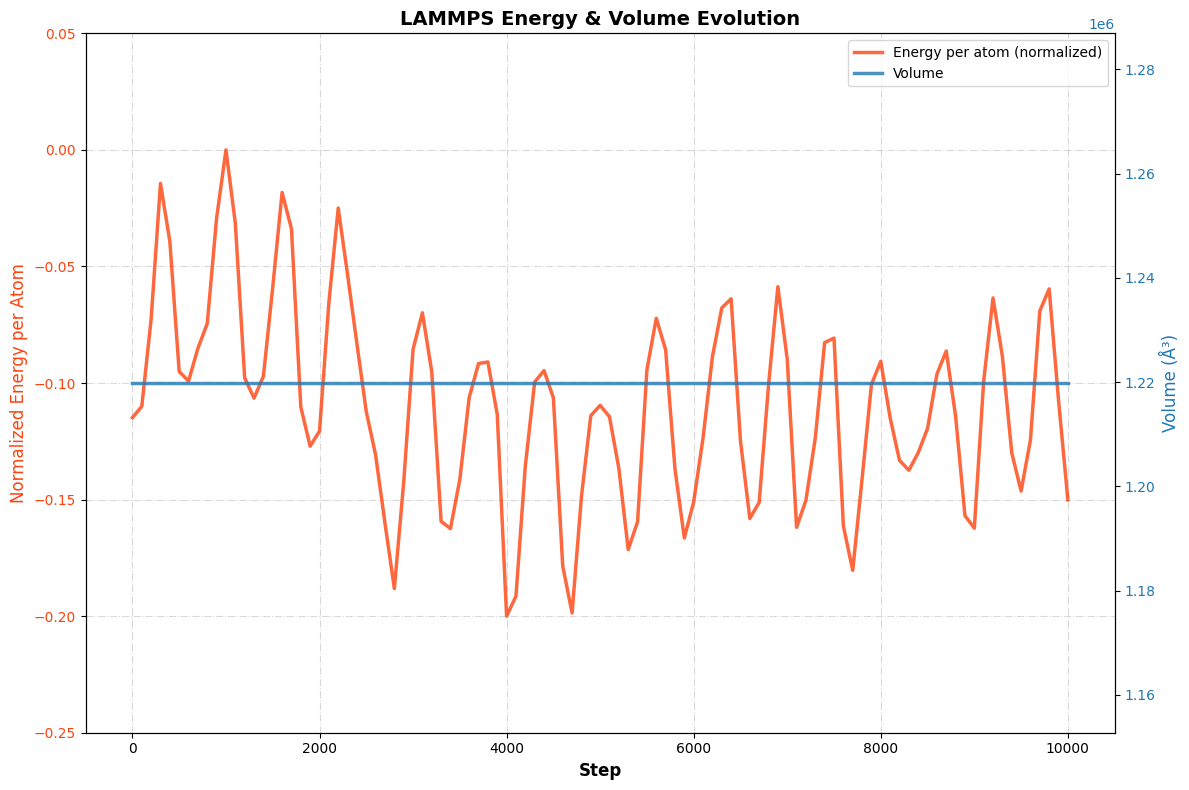


LAMMPS SIMULATION SUMMARY
Total steps: 101
Step range: 0 to 10000
Number of atoms: 132160

Energy per atom (original values):
  Initial: -7.087331 eV/atom
  Final: -7.088234 eV/atom
  Highest: -7.084390 eV/atom
  Lowest: -7.089511 eV/atom
  Change: -0.000904 eV/atom
  Average: -7.087196 eV/atom

Normalized energy range: -0.2 to 0 (highest energy = 0)
  Initial (normalized): -0.114855
  Final (normalized): -0.150143

Volume:
  Initial: 1219843.600 Å³
  Final: 1219843.600 Å³
  Change: 0.000 Å³
  Average: 1219843.600 Å³

Temperature:
  Average: 2500.62 K
  Range: 2486.04 - 2515.58 K

Pressure:
  Average: -796.94 atm
  Range: -2206.19 - 264.07 atm
✓ LAMMPS log analysis completed successfully
✓ Auto-detected 132160 atoms from log file


Uncomment the detailed analysis code above to see all thermodynamic properties


In [14]:
# =============================================================================
# LAMMPS LOG ANALYSIS - USAGE EXAMPLES
# =============================================================================

# EXAMPLE 1: Basic energy and volume evolution plot with auto-detection
# UPDATE THIS PATH to match your data location
log_file = "/Volumes/DATA/LAMMPS/plane_defect/NVT@2500K/5_2/log.lammps"

# Plot energy and volume evolution (natoms will be auto-detected)
data = plot_lammps_energy_volume_evolution(
    log_file, 
    title="LAMMPS Energy & Volume Evolution"
)

 
if data:
    print("✓ LAMMPS log analysis completed successfully")
    print(f"✓ Auto-detected {data['natoms']} atoms from log file")
else:
    print("✗ Failed to analyze log file - check file path and format")

print("\n" + "="*50)

# EXAMPLE 2: Manual override of natoms (if auto-detection fails)
# Uncomment if you need to manually specify the number of atoms

print("\n" + "="*50)

# EXAMPLE 3: Comprehensive analysis with 4 subplots
# Uncomment the lines below to run detailed analysis

print("Uncomment the detailed analysis code above to see all thermodynamic properties")

---

# 2. VASP Analysis

## 2.1 Basic VASP File Reading

Read VASP output files and extract energy and volume data.

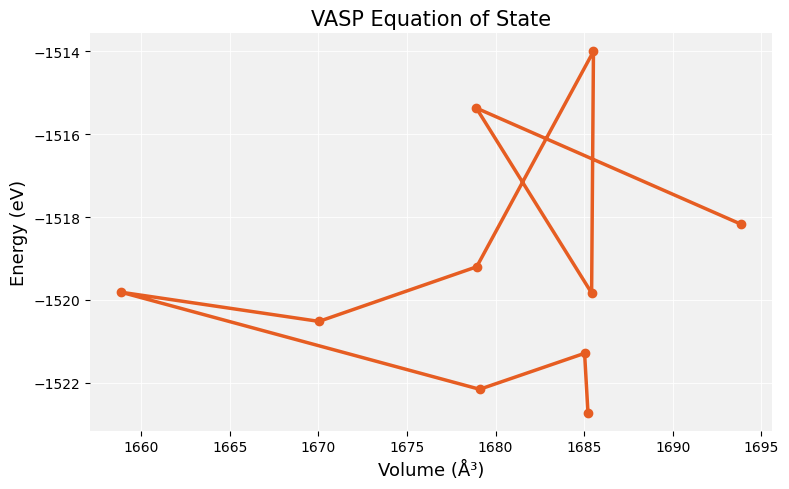

✓ VASP equation of state plotted successfully


In [240]:
# =============================================================================
# VASP BASIC ANALYSIS
# =============================================================================

def read_vasp_trajectory(vasp_file, last_n_frames=10):
    """
    Read VASP trajectory from vasprun.xml
    
    Parameters:
    vasp_file: path to vasprun.xml
    last_n_frames: number of last frames to analyze
    
    Returns:
    energies, volumes: lists of energies and volumes
    """
    try:
        images = list(iread(vasp_file, index=f'-{last_n_frames}:', format="vasp-xml"))
        if not images:
            raise ValueError("No images could be read from the vasprun.xml file.")
            
        energies = [img.get_potential_energy() for img in images]
        volumes = [img.get_volume() for img in images]
        
        return energies, volumes
        
    except Exception as e:
        print(f"Error reading VASP file: {e}")
        return [], []

def plot_vasp_equation_of_state(energies, volumes, title="VASP Equation of State"):
    """Plot VASP energy vs volume"""
    if not energies or not volumes:
        print("No data to plot.")
        return
        
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#f1f1f1")
    ax.grid(True, color='white', linestyle='-', alpha=0.8)
    ax.plot(volumes, energies, marker='o', color="#e65d22", lw=2.5)
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.xlabel('Volume (Å³)', fontsize=13)
    plt.ylabel('Energy (eV)', fontsize=13)
    plt.title(title, fontsize=15)
    plt.tight_layout()
    plt.show()

# EXAMPLE USAGE:
# Update this path to your vasprun.xml file
vasp_file = "/Volumes/DATA/VASP/6ps@300K/B-i/NPT/0/vasprun.xml"

# Read trajectory and plot
energies, volumes = read_vasp_trajectory(vasp_file, last_n_frames=10)
plot_vasp_equation_of_state(energies, volumes)

if energies:
    print("✓ VASP equation of state plotted successfully")
else:
    print("Update the file path and ensure vasprun.xml exists")

## 2.2 VASP Energy and Volume Convergence Analysis

Analyze the convergence of energy and volume during VASP calculations from OUTCAR files.

In [241]:
# =============================================================================
# VASP CONVERGENCE ANALYSIS FUNCTIONS
# =============================================================================

def find_convergence_point(energies, threshold, window_size):
    """
    Find the point where energy differences become smaller than threshold
    
    Parameters:
    energies: array of energies per atom
    threshold: convergence threshold
    window_size: number of consecutive points to check
    
    Returns:
    convergence_step: step where convergence is achieved
    """
    if len(energies) < window_size + 1:
        return None
    
    for i in range(len(energies) - window_size):
        energy_diffs = np.abs(np.diff(energies[i:i+window_size+1]))
        if np.all(energy_diffs < threshold):
            return i
    
    return None

def plot_energy_convergence(outcar_file, energy_threshold=1e-6, window_size=10, natoms_manual=None):
    """
    Plot energy and volume convergence from VASP OUTCAR file
    
    Parameters:
    outcar_file: path to OUTCAR file
    energy_threshold: threshold for convergence detection
    window_size: window size for convergence analysis
    natoms_manual: manual override for number of atoms
    
    Returns:
    time_steps, energies_per_atom, convergence_step
    """
    try:
        with open(outcar_file, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File {outcar_file} not found!")
        return None, None, None
    except Exception as e:
        print(f"Error reading file: {e}")
        return None, None, None
    
    # Extract data
    energies = []
    volumes = []
    ionic_steps = []
    natoms = natoms_manual
    
    # Auto-detect number of atoms if not provided
    if natoms is None:
        for line in lines:
            if "NIONS" in line:
                try:
                    if "number of ions     NIONS =" in line:
                        natoms = int(line.split("NIONS =")[1].strip().split()[0])
                        break
                    elif "NIONS =" in line and line.split("NIONS =")[1].strip():
                        parts = line.split("NIONS =")[1].strip().split()
                        if parts:
                            natoms = int(parts[0])
                            break
                except (ValueError, IndexError):
                    continue
        
        if natoms is None:
            for line in lines:
                if "ions per type" in line:
                    try:
                        counts = [int(x) for x in line.split()[4:]]
                        natoms = sum(counts)
                        print(f"Found natoms from 'ions per type': {natoms}")
                        break
                    except:
                        continue
    
    if natoms is None:
        print("Error: Could not determine number of atoms")
        print("Please provide natoms_manual parameter")
        return None, None, None
    
    print(f"Using {natoms} atoms {'(manual)' if natoms_manual else '(auto-detected)'}")
    
    # Extract energies, volumes and ionic steps
    current_step = 0
    for i, line in enumerate(lines):
        if "--------------------------------------- Ionic step" in line:
            try:
                current_step = int(line.split("Ionic step")[1].split("---")[0].strip())
            except:
                current_step += 1
        
        if "total energy   ETOTAL" in line and "eV" in line:
            try:
                parts = line.split("=")
                if len(parts) > 1:
                    energy = float(parts[1].split()[0])
                    energies.append(energy)
                    ionic_steps.append(current_step)
            except:
                pass
        
        if "volume of cell :" in line:
            try:
                volume = float(line.split(':')[1].strip().split()[0])
                volumes.append(volume)
            except:
                pass
    
    if not energies or not volumes:
        print("No energy or volume data found in OUTCAR")
        return None, None, None
    
    # Ensure same length
    min_length = min(len(energies), len(volumes))
    energies = energies[:min_length]
    volumes = volumes[:min_length]
    ionic_steps = ionic_steps[:min_length]
    
    print(f"Found {len(energies)} energy values and {len(volumes)} volume values")
    
    # Convert to per atom and normalize
    energies_per_atom = np.array(energies) / natoms
    volumes_array = np.array(volumes)
    time_steps = np.array(ionic_steps)
    
    max_energy = np.max(energies_per_atom)
    normalized_energy = energies_per_atom - max_energy
    
    min_volume = np.min(volumes_array)
    normalized_volume = volumes_array - min_volume
    
    # Find convergence point
    convergence_step = find_convergence_point(energies_per_atom, energy_threshold, window_size)
    
    # Create dual-axis plot
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    # Energy plot (left axis)
    color1 = "#6C0A90"
    ax1.set_xlabel('Ionic Step', fontsize=12)
    ax1.set_ylabel('Energy Difference (eV/atom)', fontsize=12, color=color1)
    line1 = ax1.plot(time_steps, normalized_energy, '-', linewidth=2.5, color=color1, label='Energy')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.6, linestyle='-.', color='gray')
    ax1.set_ylim(-0.75, 0.1)  # Fixed energy scale
    
    # Volume plot (right axis)
    ax2 = ax1.twinx()
    color2 = "#FF1F1F"
    ax2.set_ylabel('Volume Difference (Å³)', fontsize=12, color=color2)
    line2 = ax2.plot(time_steps, normalized_volume, '-', linewidth=2.5, color=color2, label='Volume')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(-10, 300)
    
    # Mark convergence point
    if convergence_step is not None and convergence_step < len(time_steps):
        conv_x = time_steps[convergence_step]
        conv_y1 = normalized_energy[convergence_step]
        conv_y2 = normalized_volume[convergence_step]
        
        ax1.plot(conv_x, conv_y1, 'ro', markersize=10)
        ax2.plot(conv_x, conv_y2, 'bo', markersize=10)
        
        x_middle = (min(time_steps) + max(time_steps)) / 2
        y_bottom = min(normalized_energy) + (max(normalized_energy) - min(normalized_energy)) * 0.1
        
        ax1.annotate(f'Convergence\nStep {conv_x}', 
                    xy=(conv_x, conv_y1), 
                    xytext=(x_middle, y_bottom),
                    arrowprops=dict(arrowstyle='->', color='#C1F80A', lw=2),
                    fontsize=10, ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFFCB', alpha=0.7))
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    
    plt.title('VASP Energy and Volume Convergence Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"Total ionic steps: {len(time_steps)}")
    print(f"Initial energy per atom: {energies_per_atom[0]:.6f} eV/atom")
    print(f"Final energy per atom: {energies_per_atom[-1]:.6f} eV/atom")
    print(f"Energy change: {energies_per_atom[-1] - energies_per_atom[0]:.6f} eV/atom")
    print(f"Initial volume: {volumes_array[0]:.3f} Å³")
    print(f"Final volume: {volumes_array[-1]:.3f} Å³")
    print(f"Volume change: {volumes_array[-1] - volumes_array[0]:.3f} Å³")
    
    return time_steps, energies_per_atom, convergence_step

Using 162 atoms (manual)
Found 10000 energy values and 10000 volume values
Found 10000 energy values and 10000 volume values


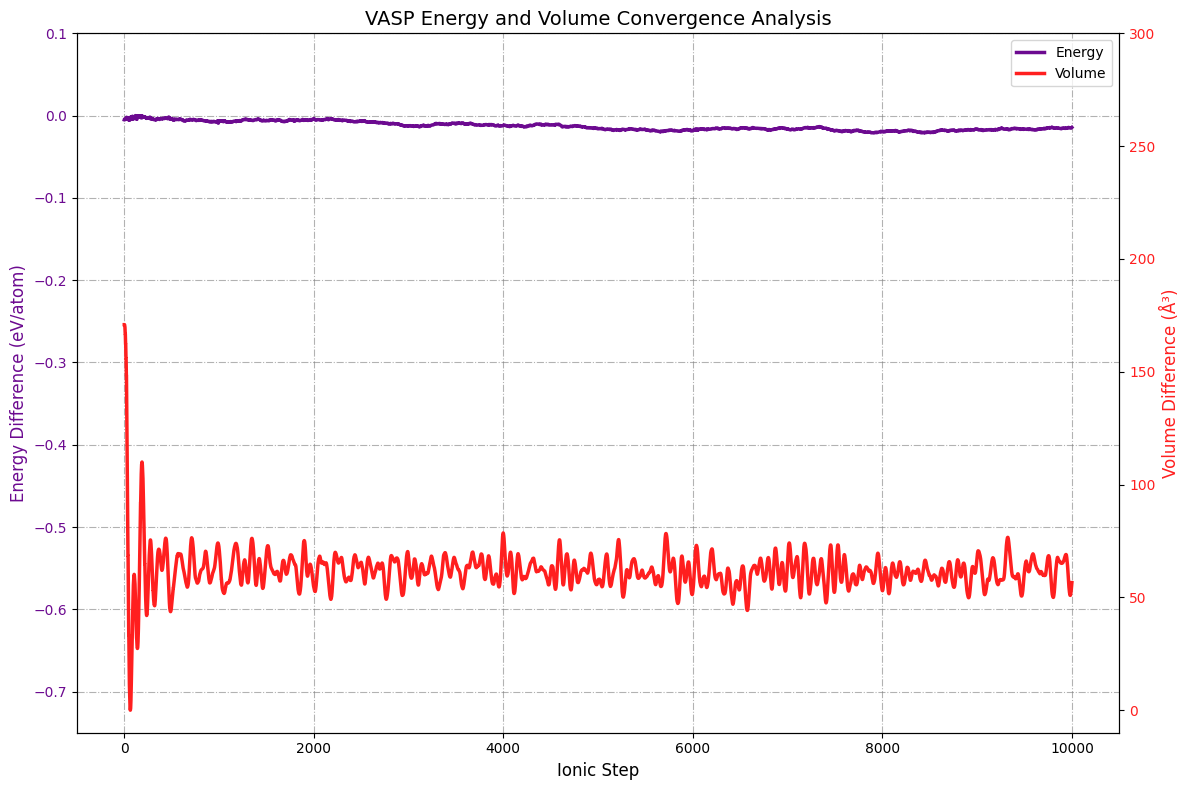

Total ionic steps: 10000
Initial energy per atom: -7.829348 eV/atom
Final energy per atom: -7.838577 eV/atom
Energy change: -0.009228 eV/atom
Initial volume: 1712.335 Å³
Final volume: 1597.970 Å³
Volume change: -114.365 Å³
✓ Energy convergence analysis completed successfully
⚠ System has not converged within the specified criteria
  Consider using a larger threshold or analyzing the full trajectory


In [247]:
# =============================================================================
# VASP CONVERGENCE ANALYSIS - USAGE EXAMPLE
# =============================================================================

# EXAMPLE: Analyze energy and volume convergence
# UPDATE THIS PATH to your OUTCAR file
outcar_path = '/Volumes/DATA/VASP/interface@300K/NPT/50/OUTCAR'

# Run convergence analysis
result = plot_energy_convergence(
    outcar_path, 
    energy_threshold=1e-6,  # Energy convergence threshold (eV/atom)
    window_size=15,         # Number of consecutive steps to check
    natoms_manual=162       # Number of atoms (set to None for auto-detection)
)

if result[0] is not None:
    time_steps, energies_per_atom, convergence_step = result
    print("✓ Energy convergence analysis completed successfully")
    
    if convergence_step is not None:
        print(f"✓ System converged at step {time_steps[convergence_step]}")
        print(f"  Recommendation: Use configurations from step {time_steps[convergence_step]} onwards")
    else:
        print("⚠ System has not converged within the specified criteria")
        print("  Consider using a larger threshold or analyzing the full trajectory")
else:
    print("✗ Convergence analysis failed - check file path and format")

## 2.3 VASP Stress Tensor Analysis

Analyze stress evolution during VASP calculations, separating tensile and shear components.

In [248]:
# =============================================================================
# VASP STRESS ANALYSIS FUNCTIONS
# =============================================================================

def plot_stress_convergence(outcar_file, stress_threshold=1.0, window_size=10):
    """
    Plot stress tensor evolution from VASP OUTCAR file
    Separates tensile (XX, YY, ZZ) and shear (XY, YZ, XZ) components
    
    Parameters:
    outcar_file: path to OUTCAR file
    stress_threshold: threshold for stress analysis (not used currently)
    window_size: window size for analysis (not used currently)
    
    Returns:
    time_steps, stress_array: time steps and stress tensor data
    """
    try:
        with open(outcar_file, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File {outcar_file} not found!")
        return None
    except Exception as e:
        print(f"Error reading file: {e}")
        return None
    
    # Extract stress data
    stress_data = []
    ionic_steps = []
    current_step = 0
    
    for i, line in enumerate(lines):
        if "--------------------------------------- Ionic step" in line:
            try:
                current_step = int(line.split("Ionic step")[1].split("---")[0].strip())
            except:
                current_step += 1
        
        # Extract stress data
        if "in kB" in line and "external pressure" not in line:
            try:
                parts = line.split()
                if len(parts) >= 8 and parts[0] == "in" and parts[1] == "kB":
                    stress_values = [float(x) for x in parts[2:8]]
                    stress_data.append(stress_values)
                    ionic_steps.append(current_step)
            except:
                pass
    
    if not stress_data:
        print("No stress data found in OUTCAR")
        return None
    
    print(f"Found {len(stress_data)} stress data points")
    
    # Convert to numpy arrays
    stress_array = np.array(stress_data)  # Shape: (n_steps, 6)
    time_steps = np.array(ionic_steps)
    stress_labels = ['XX', 'YY', 'ZZ', 'XY', 'YZ', 'XZ']
    
    # Create side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Define colors for tensile and shear stresses
    tensile_colors = ['#FF6B6B', '#00008B', '#45B7D1']  # Red to blue gradient
    shear_colors = ['#96CEB4', '#FFEAA7', '#DDA0DD']    # Green to yellow to purple
    
    # Plot tensile stress components (XX, YY, ZZ)
    for i in range(3):
        ax1.plot(time_steps, stress_array[:, i], '-',
               linewidth=2.5, color=tensile_colors[i], 
               label=f'σ_{stress_labels[i]}')
    
    ax1.set_xlabel('Ionic Step', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Tensile Stress (kB)', fontsize=12, fontweight='bold')
    ax1.set_title('Tensile Stress Components (σ_XX, σ_YY, σ_ZZ)', 
                  fontsize=12, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, linestyle='-.', color='gray')
    ax1.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    # Plot shear stress components (XY, YZ, XZ)
    for i in range(3):
        ax2.plot(time_steps, stress_array[:, i+3], '-',
               linewidth=2.5, color=shear_colors[i],
               label=f'τ_{stress_labels[i+3]}')

    ax2.set_xlabel('Ionic Step', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Shear Stress (kB)', fontsize=12, fontweight='bold')
    ax2.set_title('Shear Stress Components (τ_XY, τ_YZ, τ_XZ)', 
                  fontsize=12, fontweight='bold', pad=20)
    ax2.grid(True, alpha=0.3, linestyle='-.', color='gray')
    ax2.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    # Add main title
    fig.suptitle('VASP Stress Tensor Evolution (Raw Values)', 
                 fontsize=18, fontweight='bold', y=0.9)

    # Adjust layout
    plt.subplots_adjust(top=0.85, wspace=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    
    # Print summary statistics
    print(f"Total ionic steps: {len(time_steps)}")
    print("\nTensile stress ranges (kB):")
    for i in range(3):
        label = stress_labels[i]
        min_val = np.min(stress_array[:, i])
        max_val = np.max(stress_array[:, i])
        print(f"  σ_{label}: {min_val:.3f} to {max_val:.3f} (range: {max_val - min_val:.3f})")
    
    print("\nShear stress ranges (kB):")
    for i in range(3, 6):
        label = stress_labels[i]
        min_val = np.min(stress_array[:, i])
        max_val = np.max(stress_array[:, i])
        print(f"  τ_{label}: {min_val:.3f} to {max_val:.3f} (range: {max_val - min_val:.3f})")
    
    print("\nFinal stress values (kB):")
    print("Tensile:")
    for i in range(3):
        label = stress_labels[i]
        final_val = stress_array[-1, i]
        print(f"  σ_{label}: {final_val:.3f}")
    
    print("Shear:")
    for i in range(3, 6):
        label = stress_labels[i]
        final_val = stress_array[-1, i]
        print(f"  τ_{label}: {final_val:.3f}")
    
    return time_steps, stress_array

Found 10371 stress data points


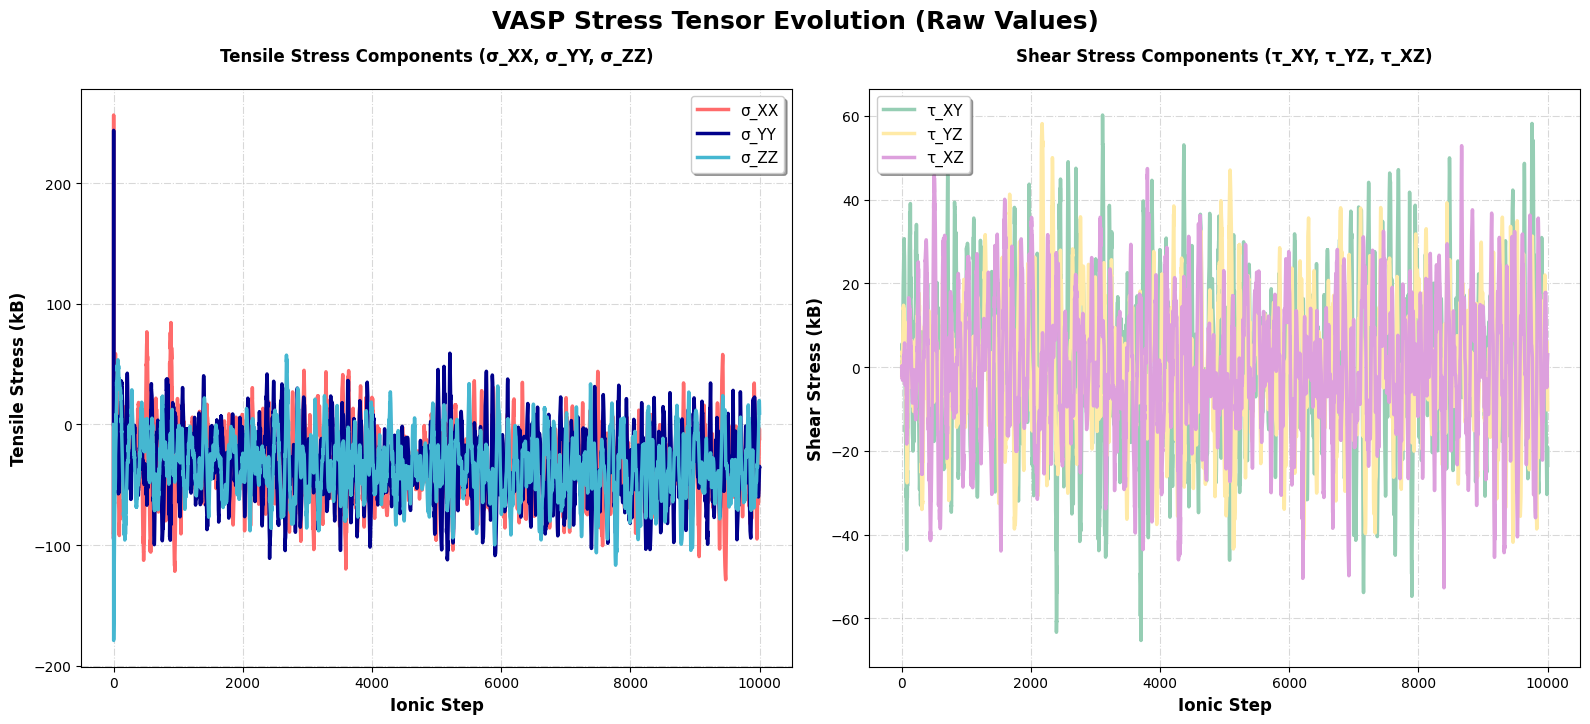

Total ionic steps: 10371

Tensile stress ranges (kB):
  σ_XX: -128.621 to 256.354 (range: 384.975)
  σ_YY: -112.110 to 243.647 (range: 355.757)
  σ_ZZ: -178.915 to 57.444 (range: 236.359)

Shear stress ranges (kB):
  τ_XY: -65.296 to 60.197 (range: 125.493)
  τ_YZ: -43.440 to 58.149 (range: 101.589)
  τ_XZ: -52.711 to 52.876 (range: 105.586)

Final stress values (kB):
Tensile:
  σ_XX: -11.687
  σ_YY: -35.016
  σ_ZZ: 9.433
Shear:
  τ_XY: -23.484
  τ_YZ: -10.188
  τ_XZ: 2.946
✓ Stress analysis completed for 10371 ionic steps


In [249]:
# =============================================================================
# VASP STRESS ANALYSIS - USAGE EXAMPLE
# =============================================================================

# EXAMPLE: Analyze stress tensor evolution
# Update this path to your OUTCAR file
outcar_path = '/Volumes/DATA/VASP/interface@2500K/NPT/50/OUTCAR'

# Run stress analysis
stress_results = plot_stress_convergence(outcar_path, stress_threshold=1.0, window_size=15)

if stress_results:
    time_steps, stress_array = stress_results
    print(f"✓ Stress analysis completed for {len(time_steps)} ionic steps")
else:
    print("✗ Stress analysis failed - check file path")

---

# 3. Advanced RDF Analysis with OVITO

## 3.1 Partial RDF Calculation

Calculate partial radial distribution functions using OVITO with time averaging across multiple trajectory frames.

In [250]:
# =============================================================================
# OVITO PARTIAL RDF ANALYSIS FUNCTIONS
# =============================================================================

def calculate_ovito_partial_rdf(dump_file, cutoff=5.5, bins=110, time_average=True):
    """
    Calculate partial RDF using OVITO with optional time averaging
    
    Parameters:
    dump_file: path to LAMMPS dump file
    cutoff: cutoff distance for RDF calculation
    bins: number of bins for RDF
    time_average: whether to average over all frames
    
    Returns:
    distances, partial_rdfs: distance array and dictionary of partial RDFs
    """
    # Load trajectory
    pipeline = import_file(dump_file)
    print(f"Number of MD frames: {pipeline.source.num_frames}")
    
    # Add coordination analysis modifier
    coordination_modifier = CoordinationAnalysisModifier(
        cutoff=cutoff, 
        number_of_bins=bins, 
        partial=True
    )
    pipeline.modifiers.append(coordination_modifier)
    
    # Add time averaging if requested
    if time_average:
        time_averaging = TimeAveragingModifier(operate_on='table:coordination-rdf')
        pipeline.modifiers.append(time_averaging)
    
    # Compute the pipeline
    data = pipeline.compute()
    print("Partial RDFs calculated")
    
    # Extract RDF table
    rdf_table = data.tables['coordination-rdf']
    print(f"Available columns: {list(rdf_table.keys())}")
    
    # Extract distance and RDF data
    distances = np.array(rdf_table['Distance'])
    
    partial_rdfs = {}
    for column_name in rdf_table.keys():
        if 'RDF' in column_name and column_name != 'RDF':
            partial_rdfs[column_name] = np.array(rdf_table[column_name])
            print(f"Found partial RDF: {column_name}")
    
    return distances, partial_rdfs

def plot_partial_rdfs(distances, partial_rdfs, title="Partial RDFs"):
    """
    Plot partial RDFs with professional styling
    
    Parameters:
    distances: distance array
    partial_rdfs: dictionary of partial RDF data
    title: plot title
    """
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    
    # Grid styling
    ax.grid(True, color='gray', linestyle='-.', linewidth=1, alpha=0.5)
    ax.set_axisbelow(True)
    
    # Define colors for different pair types
    pair_colors = {
        'B-B': "#ff420e",     # Orange for B-B pairs
        'Ti-Ti': "#4c944cff", # Green for Ti-Ti pairs  
        'B-Ti': "#650021",    # Dark red for B-Ti pairs
        'Ti-B': "#650021"     # Same as B-Ti
    }
    
    # Plot each partial RDF
    for column_name, rdf_values in partial_rdfs.items():
        # Determine color and label based on column name
        color = "#9467bd"  # default purple
        label = column_name
        
        # Check for different naming conventions
        if any(x in column_name.upper() for x in ['B-B', 'BB']):
            color = pair_colors['B-B']
            label = 'B-B'
        elif any(x in column_name.upper() for x in ['TI-TI', 'TITI']):
            color = pair_colors['Ti-Ti'] 
            label = 'Ti-Ti'
        elif any(x in column_name.upper() for x in ['B-TI', 'TI-B', 'BTI', 'TIB']):
            color = pair_colors['B-Ti']
            label = 'B-Ti'
        
        # Plot the partial RDF
        ax.plot(distances, rdf_values, 
               color=color, 
               linewidth=3.0, 
               label=f'{label} (Time-Averaged)', 
               alpha=0.9)
        
        max_g = np.max(rdf_values)
        max_r = distances[np.argmax(rdf_values)]
        print(f"Plotted {label}: Max g(r) = {max_g:.3f} at r = {max_r:.3f} Å")
    
    # Professional styling
    ax.set_xlabel('Distance r (Å)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Radial Distribution Function g(r)', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    
    # Legend styling
    legend = ax.legend(fontsize=12, 
                      frameon=True, 
                      fancybox=True, 
                      shadow=True,
                      framealpha=0.95,
                      edgecolor='#bdc3c7',
                      facecolor='white',
                      loc='upper right')
    legend.get_frame().set_linewidth(0.8)
    
    # Set axis limits
    ax.set_xlim(0, 5.5)
    ax.set_ylim(bottom=0)
    
    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    print("\n" + "="*60)
    print("PARTIAL RDF ANALYSIS SUMMARY")
    print("="*60)
    for column_name, rdf_values in partial_rdfs.items():
        max_idx = np.argmax(rdf_values)
        max_distance = distances[max_idx]
        max_value = rdf_values[max_idx]
        
        # Find first coordination shell (first peak)
        first_peak_idx = np.argmax(rdf_values[:len(rdf_values)//3])
        first_peak_distance = distances[first_peak_idx]
        first_peak_value = rdf_values[first_peak_idx]
        
        print(f"{column_name}:")
        print(f"  First peak: g(r) = {first_peak_value:.3f} at r = {first_peak_distance:.3f} Å")
        print(f"  Global max: g(r) = {max_value:.3f} at r = {max_distance:.3f} Å")
        print()
    print("="*60)

In [251]:
# =============================================================================
# OVITO PARTIAL RDF - USAGE EXAMPLE
# =============================================================================

# EXAMPLE: Calculate and plot partial RDFs using OVITO
# Update this path to your LAMMPS dump file
dump_file = "/Volumes/DATA/LAMMPS/interface@300K/NPT/50/relax.dump"

# Calculate partial RDFs
distances, partial_rdfs = calculate_ovito_partial_rdf(
    dump_file, 
    cutoff=5.5,      # Cutoff distance in Angstroms
    bins=110,        # Number of bins for RDF
    time_average=True # Average over all trajectory frames
)

if partial_rdfs:
    plot_partial_rdfs(distances, partial_rdfs, 
                     title="Partial RDFs: B-B, Ti-Ti, and B-Ti (Time-Averaged)")
    print("✓ Partial RDF analysis completed successfully")
else:
    print("✗ No partial RDF data found - check file path")

Number of MD frames: 1001
Partial RDFs calculated
Available columns: ['g(r)']
Partial RDFs calculated
Available columns: ['g(r)']


KeyError: "The points property with the name 'Distance' does not exist or has not been computed by the pipeline."

In [ ]:
# =============================================================================
# RDF DATA MANAGEMENT FUNCTIONS
# =============================================================================

def calculate_and_save_vasp_rdf(xdatcar_path, save_path):
    """Calculate VASP RDFs and save to file"""
    try:
        print(f"Reading VASP XDATCAR file: {xdatcar_path}")
        xd = Xdatcar(xdatcar_path)
        print(f"Loaded {len(xd.structures)} VASP structures")
        
        # Calculate all RDFs
        rdf_b_b_vasp = RadialDistributionFunction.from_species_strings(
            structures=xd.structures, species_i='B', species_j='B'
        )
        rdf_ti_ti_vasp = RadialDistributionFunction.from_species_strings(
            structures=xd.structures, species_i='Ti', species_j='Ti'
        )
        rdf_b_ti_vasp = RadialDistributionFunction.from_species_strings(
            structures=xd.structures, species_i='B', species_j='Ti'
        )
        
        # Prepare data for saving
        vasp_data = {
            'r': rdf_b_b_vasp.r,
            'b_b_rdf': rdf_b_b_vasp.smeared_rdf(),
            'ti_ti_rdf': rdf_ti_ti_vasp.smeared_rdf(),
            'b_ti_rdf': rdf_b_ti_vasp.smeared_rdf()
        }
        
        # Save to file
        with open(save_path, 'wb') as f:
            pickle.dump(vasp_data, f)
        
        print(f"VASP RDF data saved to: {save_path}")
        return vasp_data
        
    except Exception as e:
        print(f"Error in VASP RDF calculation: {e}")
        return None

def calculate_and_save_lammps_rdf(dump_path, save_path):
    """Calculate LAMMPS RDFs and save to file"""
    try:
        pipeline = import_file(dump_path)
        
        coordination_modifier = CoordinationAnalysisModifier(
            cutoff=5.5, 
            number_of_bins=110,
            partial=True
        )
        pipeline.modifiers.append(coordination_modifier)
        
        time_averaging = TimeAveragingModifier(operate_on='table:coordination-rdf')
        pipeline.modifiers.append(time_averaging)
        
        data = pipeline.compute()
        rdf_table = data.tables['coordination-rdf']
        
        rdf_data = rdf_table.xy()
        distances = rdf_data[:, 0]
        
        rdf_names = rdf_table.y.component_names
        partial_rdfs = {}
        
        for component, name in enumerate(rdf_names):
            rdf_values = rdf_data[:, component + 1]
            partial_rdfs[name] = rdf_values
        
        # Prepare data for saving
        lammps_data = {
            'distances': distances,
            'partial_rdfs': partial_rdfs
        }
        
        # Save to file
        with open(save_path, 'wb') as f:
            pickle.dump(lammps_data, f)
        
        print(f"LAMMPS RDF data saved to: {save_path}")
        return lammps_data
        
    except Exception as e:
        print(f"Error in LAMMPS RDF calculation: {e}")
        return None

def load_rdf_data(vasp_path, lammps_path):
    """Load previously calculated RDF data"""
    try:
        # Load VASP data
        with open(vasp_path, 'rb') as f:
            vasp_data = pickle.load(f)
        
        # Load LAMMPS data
        with open(lammps_path, 'rb') as f:
            lammps_data = pickle.load(f)
        
        print("✓ RDF data loaded successfully!")
        return vasp_data, lammps_data
        
    except FileNotFoundError:
        print("ERROR: RDF data files not found!")
        print("Please run the data generation first.")
        return None, None

In [ ]:
# =============================================================================
# RDF DATA GENERATION - USAGE EXAMPLE
# =============================================================================

# EXAMPLE: Generate and save RDF data (run this once)
# Update these paths to match your data

vasp_xdatcar = "/Volumes/DATA/VASP/interface@300K/NVT/100/XDATCAR"
lammps_dump = "/Volumes/DATA/LAMMPS/interface@300K/NVT/100/relax.dump"

vasp_save_path = "/Users/duygusenturk/Desktop/TU_Wien/vasp_rdf_data.pkl"
lammps_save_path = "/Users/duygusenturk/Desktop/TU_Wien/lammps_rdf_data.pkl"

# Generate and save data (uncomment to run)
"""
print("=== GENERATING RDF DATA ===")
print("This may take a while but only needs to be done once...")

# Calculate VASP data
vasp_data = calculate_and_save_vasp_rdf(vasp_xdatcar, vasp_save_path)

# Calculate LAMMPS data  
lammps_data = calculate_and_save_lammps_rdf(lammps_dump, lammps_save_path)

print("=== DATA GENERATION COMPLETE ===")
"""

print("Update the file paths and uncomment the code to generate RDF data")

## 4.2 Compare VASP vs LAMMPS RDFs

Load and compare RDF data from VASP and LAMMPS calculations.

In [ ]:
# =============================================================================
# VASP vs LAMMPS RDF COMPARISON
# =============================================================================

def plot_vasp_lammps_comparison(vasp_data, lammps_data, title="VASP vs LAMMPS RDF Comparison"):
    """
    Compare VASP and LAMMPS RDF data with scaling
    
    Parameters:
    vasp_data: VASP RDF data dictionary
    lammps_data: LAMMPS RDF data dictionary
    title: plot title
    """
    if vasp_data is None or lammps_data is None:
        print("Error: Missing RDF data")
        return
    
    # Calculate scaling factors to match peak heights
    scaling_factors = {}
    for name, rdf_values in lammps_data['partial_rdfs'].items():
        if 'B' in name and 'Ti' not in name and name.count('B') == 2:
            vasp_max = np.max(vasp_data['b_b_rdf'])
            lammps_max = np.max(rdf_values)
            scaling_factors['B-B'] = vasp_max / lammps_max if lammps_max > 0 else 1
        elif 'Ti' in name and 'B' not in name and name.count('Ti') == 2:
            vasp_max = np.max(vasp_data['ti_ti_rdf'])
            lammps_max = np.max(rdf_values)
            scaling_factors['Ti-Ti'] = vasp_max / lammps_max if lammps_max > 0 else 1
        elif ('B' in name and 'Ti' in name) or ('Ti' in name and 'B' in name):
            vasp_max = np.max(vasp_data['b_ti_rdf'])
            lammps_max = np.max(rdf_values)
            scaling_factors['B-Ti'] = vasp_max / lammps_max if lammps_max > 0 else 1
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Set styling
    ax.set_facecolor("#ffffff")
    for spine in ax.spines.values():
        spine.set_color("#333333")
        spine.set_linewidth(1.5)
    
    # Define colors
    pair_colors = {
        'B-B': "#F0C571",     
        'Ti-Ti': "#E02B35",  
        'B-Ti': "#082a54"    
    }
    
    # Plot VASP data (solid lines)
    ax.plot(vasp_data['r'], vasp_data['b_b_rdf'], 
           color=pair_colors['B-B'], linewidth=2, 
           linestyle='-', label='VASP B-B')
    
    ax.plot(vasp_data['r'], vasp_data['ti_ti_rdf'], 
           color=pair_colors['Ti-Ti'], linewidth=2, 
           linestyle='-', label='VASP Ti-Ti')
    
    ax.plot(vasp_data['r'], vasp_data['b_ti_rdf'], 
           color=pair_colors['B-Ti'], linewidth=2, 
           linestyle='-', label='VASP B-Ti')
    
    # Plot LAMMPS data (dashed lines) with scaling
    for name, rdf_values in lammps_data['partial_rdfs'].items():
        if 'B' in name and 'Ti' not in name and name.count('B') == 2:
            color = pair_colors['B-B']
            label = 'LAMMPS B-B'
            scaled_rdf = rdf_values * scaling_factors.get('B-B', 1)
        elif 'Ti' in name and 'B' not in name and name.count('Ti') == 2:
            color = pair_colors['Ti-Ti'] 
            label = 'LAMMPS Ti-Ti'
            scaled_rdf = rdf_values * scaling_factors.get('Ti-Ti', 1)
        elif ('B' in name and 'Ti' in name) or ('Ti' in name and 'B' in name):
            color = pair_colors['B-Ti']
            label = 'LAMMPS B-Ti'
            scaled_rdf = rdf_values * scaling_factors.get('B-Ti', 1)
        else:
            continue
        
        ax.plot(lammps_data['distances'], scaled_rdf, 
               color=color, linewidth=2, 
               linestyle='-.', label=label)
    
    # Formatting
    ax.set_xlabel('Distance r (Å)', fontsize=16, color='#333333')
    ax.set_ylabel('g(r)', fontsize=16, color='#333333')
    ax.set_title(title, fontsize=16, color='#333333')
    ax.legend(facecolor='white', edgecolor='#bdc3c7', fontsize=10)
    ax.set_xlim(1, 5.5)
    ax.grid(True, color='gray', alpha=0.3, linestyle='-.')
    plt.show()

# EXAMPLE USAGE:
# Load and compare RDF data
vasp_path = "/Users/duygusenturk/Desktop/TU_Wien/vasp_rdf_data.pkl"
lammps_path = "/Users/duygusenturk/Desktop/TU_Wien/lammps_rdf_data.pkl"

# Load and compare
vasp_data, lammps_data = load_rdf_data(vasp_path, lammps_path)

if vasp_data and lammps_data:
    plot_vasp_lammps_comparison(vasp_data, lammps_data, 
                               title="Partial RDF Comparison: VASP vs LAMMPS")
    print("✓ RDF comparison completed successfully")
else:
    print("✗ Could not load RDF data for comparison")
    print("Run the data generation cell first")

NameError: name 'load_rdf_data' is not defined

---

# 5. Tips and Troubleshooting

## Common Issues and Solutions

### File Path Issues
- Always use absolute paths or ensure your working directory is correct
- Check that files exist before running analysis
- Update all example paths to match your data structure

### Memory Issues
- For large trajectory files, consider analyzing fewer frames
- Use time averaging in OVITO to reduce memory usage
- Process data in chunks if necessary

### VASP Analysis
- Ensure OUTCAR files are complete (check for "reached required accuracy")
- For convergence analysis, adjust thresholds based on your system
- Number of atoms detection usually works automatically, but manual override is available

### RDF Calculations
- Choose appropriate cutoff distances (typically 5-8 Å)
- Increase bin numbers for smoother curves
- Time averaging improves statistics but requires more memory

## Customization Options

### Plotting Styles
- Modify colors in the `pair_colors` dictionaries
- Adjust figure sizes in `plt.subplots(figsize=(x, y))`
- Change line styles and markers for different aesthetics

### Analysis Parameters
- Energy convergence thresholds: adjust based on desired precision
- RDF cutoffs: increase for longer-range analysis
- Stress analysis: modify scaling or add normalization

### Output Formats
- Save plots using `plt.savefig('filename.png', dpi=300, bbox_inches='tight')`
- Export data using numpy: `np.savetxt('data.txt', array)`
- Use pickle for complex data structures


---

